# ECOWAS Border Trade Intelligence and Analytics

# Machine Learning for Border Intelligence

## Impact Assessment of Simulated Regional Trade Diversion Following the AES Countries' Withdrawal from ECOWAS

### Case Study: Tsamiya–Kamba Transit Corridor

---

## Objective

This notebook demonstrates how Machine Learning can support border management by predicting the likelihood of high-risk shipments using historical transaction data.

The workflow includes data preparation, feature engineering, model training, evaluation, and interpretation of results.

In [26]:
# ============================================================
# Chapter 1 - Import Libraries
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [27]:
# ============================================================
# Chapter 2 - Load Dataset
# ============================================================

df = pd.read_csv("trade_diversion_transactions.csv")

print(df.shape)

df.head()

(100000, 20)


,Transaction_ID,Transaction_Date,Period,Origin_Country,Entry_Country,Destination_Country,Border_Post,Commodity,Vehicle_Type,Cargo_Weight_kg,Trade_Value_USD,Customs_Duty_USD,Revenue_Collected_USD,Queue_Length,Processing_Time_Minutes,Inspection_Result,Smuggling_Risk,Security_Incident,Scanner_Status,Border_Efficiency_Score
0,TRX0000001,2025-08-02,After Diversion,Togo,Cape Verde,Niger,Praia Port,Vehicles,Heavy Truck,23091.78,70960.57,9435.26,9791.44,17,25.9,Passed,Medium,No,Unavailable,98.0
1,TRX0000002,2022-08-17,Before Diversion,Nigeria,Togo,Niger,Kodjoviakope,Livestock,Heavy Truck,16533.94,63340.83,11608.49,11799.07,22,48.0,Passed,Low,No,Unavailable,82.3
2,TRX0000003,2022-02-21,Before Diversion,Benin,Benin,Niger,Hillacondji,Vehicles,Passenger Bus,943.86,13943.07,2766.44,2833.49,25,46.5,Passed,Medium,No,Unavailable,76.8
3,TRX0000004,2023-07-18,Before Diversion,Benin,Sierra Leone,Nigeria,Gbalamuya,Petroleum,Heavy Truck,18142.28,83276.36,13714.69,13775.83,6,20.5,Passed,Medium,No,Available,95.3
4,TRX0000005,2023-05-17,Before Diversion,Benin,Mali,Nigeria,Gogui,Vehicles,Heavy Truck,19017.79,62190.16,10388.67,10554.40,26,54.9,Passed,Low,No,Available,79.7


## Feature Selection

Select the variables that will be used to train the machine learning model.

In [28]:
# ============================================================
# Chapter 3 - Select Variables
# ============================================================

ml_data = df[[
    "Commodity",
    "Border_Post",
    "Trade_Value_USD",
    "Queue_Length",
    "Processing_Time_Minutes",
    "Inspection_Result",
    "Security_Incident",
    "Smuggling_Risk"
]]

ml_data.head()

,Commodity,Border_Post,Trade_Value_USD,Queue_Length,Processing_Time_Minutes,Inspection_Result,Security_Incident,Smuggling_Risk
0,Vehicles,Praia Port,70960.57,17,25.9,Passed,No,Medium
1,Livestock,Kodjoviakope,63340.83,22,48.0,Passed,No,Low
2,Vehicles,Hillacondji,13943.07,25,46.5,Passed,No,Medium
3,Petroleum,Gbalamuya,83276.36,6,20.5,Passed,No,Medium
4,Vehicles,Gogui,62190.16,26,54.9,Passed,No,Low


## Data Encoding

Machine learning algorithms require numerical input. Therefore, categorical variables are converted into numeric values using Label Encoding.

In [29]:
# ============================================================
# Chapter 4 - Label Encoding
# ============================================================

encoder = LabelEncoder()

columns = [
    "Commodity",
    "Border_Post",
    "Inspection_Result",
    "Security_Incident",
    "Smuggling_Risk"
]

for column in columns:

    ml_data[column] = encoder.fit_transform(ml_data[column])

ml_data.head()

/tmp/ipykernel_777/4084221554.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_data[column] = encoder.fit_transform(ml_data[column])
/tmp/ipykernel_777/4084221554.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ml_data[column] = encoder.fit_transform(ml_data[column])
/tmp/ipykernel_777/4084221554.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

,Commodity,Border_Post,Trade_Value_USD,Queue_Length,Processing_Time_Minutes,Inspection_Result,Security_Incident,Smuggling_Risk
0,9,20,70960.57,17,25.9,1,0,2
1,4,13,63340.83,22,48.0,1,0,1
2,9,8,13943.07,25,46.5,1,0,2
3,5,6,83276.36,6,20.5,1,0,2
4,9,7,62190.16,26,54.9,1,0,1


## Define Features and Target Variable

The objective is to predict the Smuggling Risk category using operational and transaction characteristics.

In [30]:
# ============================================================
# Chapter 5 - Features and Target
# ============================================================

X = ml_data.drop(columns=["Smuggling_Risk"])

y = ml_data["Smuggling_Risk"]

print("Features:", X.shape)

print("Target:", y.shape)

Features: (100000, 7)
Target: (100000,)


## Train-Test Split

The dataset is divided into training and testing sets.

- Training data is used to build the model.
- Testing data is used to evaluate the model's performance on unseen data.

In [31]:
# ============================================================
# Chapter 6 - Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (80000, 7)
Testing set: (20000, 7)


## Decision Tree Model

A Decision Tree classifier is trained to predict the smuggling risk category.

In [32]:
# ============================================================
# Chapter 7 - Train Decision Tree
# ============================================================

model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Model Prediction

Use the trained model to predict smuggling risk for the test dataset.

In [33]:
# ============================================================
# Chapter 8 - Predictions
# ============================================================

y_pred = model.predict(X_test)

print("Predictions completed.")

Predictions completed.


## Accuracy Score

The accuracy score indicates the proportion of correctly classified observations.

In [34]:
# ============================================================
# Chapter 9 - Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 52.67%


## Confusion Matrix

The confusion matrix summarizes the model's prediction performance across the different smuggling risk classes.

In [35]:
# ============================================================
# Chapter 10 - Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

cm

array([[ 930,  766, 3360],
       [ 105, 5669, 2118],
       [ 390, 2727, 3935]])

## Classification Report

The report includes precision, recall, F1-score, and support for each class.

In [36]:
# ============================================================
# Chapter 11 - Classification Report
# ============================================================

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.18      0.29      5056
           1       0.62      0.72      0.66      7892
           2       0.42      0.56      0.48      7052

    accuracy                           0.53     20000
   macro avg       0.56      0.49      0.48     20000
weighted avg       0.56      0.53      0.50     20000



## Feature Importance

This analysis identifies which variables contributed most to the model's predictions.

In [37]:
# ============================================================
# Chapter 12 - Feature Importance
# ============================================================

importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Commodity,0.485726
2,Trade_Value_USD,0.298469
6,Security_Incident,0.208542
1,Border_Post,0.002626
4,Processing_Time_Minutes,0.002501
3,Queue_Length,0.001967
5,Inspection_Result,0.000170


## Feature Importance Visualization

This chart illustrates the relative importance of each feature in predicting the smuggling risk category.

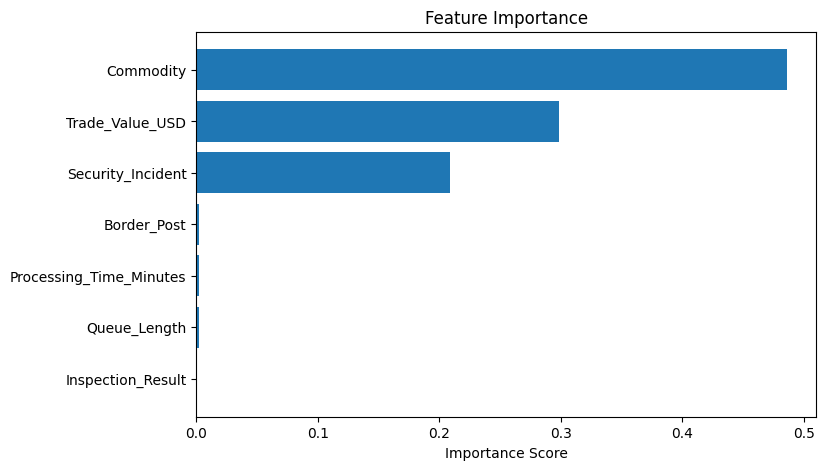

In [38]:
# ============================================================
# Chapter 13 - Feature Importance Chart
# ============================================================

import matplotlib.pyplot as plt

importance = importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(8,5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance Score")

plt.show()

## Random Forest Model

Train a Random Forest classifier and compare its performance with the Decision Tree model.

In [39]:
# ============================================================
# Chapter 14 - Random Forest
# ============================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Random Forest Accuracy

Evaluate the predictive accuracy of the Random Forest model.

In [40]:
# ============================================================
# Chapter 15 - Random Forest Accuracy
# ============================================================

rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 49.27%


## Model Comparison

Compare the accuracy of the Decision Tree and Random Forest models.

In [41]:
# ============================================================
# Chapter 16 - Model Comparison
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy,
        rf_accuracy
    ]

})

comparison

,Model,Accuracy
0,Decision Tree,0.52670
1,Random Forest,0.49265


## Export Results

Save the model comparison table for future reporting.

In [42]:
# ============================================================
# Chapter 17 - Export Results
# ============================================================

comparison.to_csv(
    "machine_learning_model_comparison.csv",
    index=False
)

print("Model comparison exported successfully.")

Model comparison exported successfully.


In [43]:
# ============================================================
# Chapter 18 - Verify Export
# ============================================================

import os

for file in sorted(os.listdir()):
    if file.endswith(".csv"):
        print(file)

machine_learning_model_comparison.csv
trade_diversion_transactions.csv


# Machine Learning Summary

This notebook demonstrated a complete supervised machine learning workflow using simulated ECOWAS border trade data.

The workflow included:

- Data preparation
- Feature selection
- Label encoding
- Train-test split
- Decision Tree classification
- Random Forest classification
- Model evaluation
- Feature importance analysis
- Model comparison

The results demonstrate how machine learning can support border intelligence by identifying patterns associated with smuggling risk and assisting decision-makers in prioritizing inspections.